# Spike Analysis Pipeline — Example Notebook

**Author:** Juliana Groß  
**Pipeline:** Spike branch — preprocessing → ISI → PSTH → postprocessing

---

## Overview

This notebook walks through the complete spike analysis pipeline step by step. It is intended to accompany the published scripts and provide an executable, annotated example to understand or reproduce the analysis.

| Step | Script | Purpose |
|------|--------|---------|
| 1 | `experiments_differential_ref_pairs.py` | Define electrode reference pairs per animal and region |
| 2 | `common_ingest.py` | Build `run_manifest.json` per recording folder |
| 3 | `preprocessing_spikes.py` | Bandpass filter (300–6000 Hz) + threshold-based spike detection |
| 4 | `process_spikes_isi.py` | Inter-spike interval histograms per channel |
| 5 | `process_spikes_psth.py` | Peri-stimulus time histograms + firing rates |
| 6 | `postprocess_spikes_isi_mainfigure.py` | Group ISI distribution + burst fraction Gardner-Altman plot |
| 7 | `postprocess_spikes_mua_firing_rate.py` | MUA firing rate as Gardner-Altman estimation plot with bootstrap CI |
| 8 | `postprocess_spikes_psth_supplement.py` | full-epoch PSTH |
| 9 | `postprocess_spikes_isi_supplement.py` | full-epoch ISI |

Steps 4, 5, and the corresponding postprocessing can be run in any order after preprocessing.
Helper functions shared across (pre-)processing scripts are defined in `Functions_preprocessing_spikes.py` and `Functions_processing_spikes.py`.

---

## Important note on the example dataset

**The example dataset used in this notebook is synthetically generated by Claude (Anthropic) for illustrative purposes.** It is not derived from real recordings. The synthetic spike trains are designed to mimic the statistical properties of real dCA1 multi-unit activity (MUA) — including realistic firing rates (~ 80–120 Hz), inter-spike interval distributions, and a stimulation-induced firing rate suppression (~20 Hz decrease) — but they do not represent actual  experimental observations.

Real data were recorded using a Tucker-Davis Technologies (TDT) system at 24 kHz with 6-wire tetrode bundles implanted bilaterally in dCA1 of freely moving mice.

---
## Setup & Imports

In [1]:
import os
import pickle
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
from scipy.ndimage import gaussian_filter1d

try:
    import dabest
    print('dabest imported successfully')
except ImportError:
    print('dabest not found. Install with: pip install dabest')

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Tool color — matches pipeline color coding
# ChR2 = cyan, vSWO = magenta, vLWO = gold
TOOL_COLOR = '#00BFFF'   # ChR2 cyan
BASE_COLOR = '#555555'   # baseline gray

# Reproducible random state
RNG = np.random.default_rng(seed=42)

# ── Epoch settings (used throughout the notebook) ────────────────────────────
FS_RAW      = 24000    # Hz  — raw TDT sampling rate
BASELINE_S  = 300.0   # s   — baseline epoch duration
STIM_S      = 300.0   # s   — stimulation epoch duration
DURATION_S  = BASELINE_S + STIM_S   # 600 s total
STIM_ONSET  = BASELINE_S            # stimulation starts at 300 s

FR_BASE     = 100.0   # Hz  — baseline firing rate
FR_STIM     =  80.0   # Hz  — stimulation firing rate (~20 Hz suppression)

print(f'Epoch layout: {BASELINE_S:.0f} s baseline + {STIM_S:.0f} s stimulation = {DURATION_S:.0f} s total')
print('All imports successful.')

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 17.26it/s]

Numba compilation complete!
dabest imported successfully
Epoch layout: 300 s baseline + 300 s stimulation = 600 s total
All imports successful.


---
## Step 1 — Experiment Dictionary (`experiments_differential_ref_pairs.py`)

Every recording session is registered in the experiment dictionary before analysis begins. For each animal and region, the following are specified:

- **`ref_pairs`**: pairs of electrode channels used for differential (local-field) referencing. The signal from one channel is subtracted from the other to remove common-mode noise while preserving local field activity. The same pairs are used for both LFP and spike preprocessing.
- **`noise_ref`**: a single channel with no electrode connected, used to record environmental noise for NLMS adaptive filtering (LFP branch only).
- **Spike detection settings** (`thresh_mult`, `polarity`, `refractory_ms`): applied uniformly across all channels of a session.

Below is a minimal example reproducing the structure used in the actual pipeline.

In [2]:
def experiment_add(experiments, ID, region="not defined", noise_ref=None,
                   ref_pairs=None, filter_type="FIR", delta1=0.00001,
                   delta2=0.0001, transition_width=50, cutoff=100,
                   num_taps=None, order=4, downsampling=1000,
                   thresh_mult=5.0, polarity='neg', refractory_ms=1.0):
    """Register one animal/region entry in the experiment dictionary."""
    if ref_pairs is None:
        ref_pairs = []
    if ID not in experiments:
        experiments[ID] = {}
    experiments[ID][region] = {
        "region": region,
        "noise_ref": noise_ref,
        "ref_pairs": ref_pairs,
        "filter": {
            "type": filter_type, "delta1": delta1, "delta2": delta2,
            "transition_width": transition_width, "cutoff": cutoff,
            "num_taps": num_taps, "order": order,
        },
        "downsampling_Hz": downsampling,
        "spike_settings": {
            "thresh_mult":    thresh_mult,    # MAD multiplier for spike threshold
            "polarity":       polarity,        # 'neg' for negative deflections
            "refractory_ms":  refractory_ms,   # minimum ISI in ms
        },
    }
    return experiments

import json

# Example: one ChR2 animal, left CA1, three differential pairs
experiments = {}
experiments = experiment_add(
    experiments,
    ID='ID1099-250114-121824',
    region='CA1_L',
    noise_ref=8,
    ref_pairs=[[31, 29], [27, 25], [23, 21]],  # [signal ch, reference ch]
    thresh_mult=5.0,
    polarity='neg',
    refractory_ms=1.0,
)

print('Experiment dictionary entry:')
print(json.dumps(experiments['ID1099-250114-121824']['CA1_L'], indent=2))

Experiment dictionary entry:
{
  "region": "CA1_L",
  "noise_ref": 8,
  "ref_pairs": [
    [
      31,
      29
    ],
    [
      27,
      25
    ],
    [
      23,
      21
    ]
  ],
  "filter": {
    "type": "FIR",
    "delta1": 1e-05,
    "delta2": 0.0001,
    "transition_width": 50,
    "cutoff": 100,
    "num_taps": null,
    "order": 4
  },
  "downsampling_Hz": 1000,
  "spike_settings": {
    "thresh_mult": 5.0,
    "polarity": "neg",
    "refractory_ms": 1.0
  }
}


---
## Step 2 — Ingest & Manifest (`common_ingest.py`)

`common_ingest.py` reads the experiment dictionary and creates a `run_manifest.json` for each recording folder. The manifest is the **single source of truth** for all downstream scripts — it stores paths, channel assignments, filter settings, and metadata references so that processing parameters are fully reproducible.

The spike and LFP branches share the same manifest. Spike scripts read `spike_settings` from the manifest; LFP scripts read `lfp_settings`.

Below we build a minimal in-memory manifest to illustrate its structure.

In [3]:
# Simulated manifest — in the real pipeline this is written to disk
# as run_manifest.json by common_ingest.py
manifest = {
    'schema_version': '1.0',
    'folder':          'ID1099-250114-121824',
    'block_path':      '/data/raw/ChR2_cohort/OFT/ID1099-250114-121824',
    'processed_folder_path': '/data/processed/ChR2_cohort/OFT/ID1099-250114-121824',
    'noise_reference_channel': 8,
    'regions': [
        {
            'region_name': 'CA1_L',
            'ref_pairs':   [[31, 29], [27, 25], [23, 21]],
            'channels_unreferenced': [21, 23, 25, 27, 29, 31],
            'spike_settings': {
                'thresh_mult':   5.0,    # MAD multiplier for spike threshold
                'polarity':      'neg',  # negative deflections
                'refractory_ms': 1.0,   # minimum ISI in ms
            },
            'lfp_settings': {
                'filter': {
                    'type': 'FIR', 'delta1': 0.00001, 'delta2': 0.0001,
                    'transition_width': 50, 'cutoff': 100,
                    'num_taps': None, 'order': 4,
                },
                'downsampling_Hz': 1000,
            },
        }
    ],
}

print('Manifest structure:')
print(f"  folder              : {manifest['folder']}")
print(f"  regions             : {[r['region_name'] for r in manifest['regions']]}")
print(f"  noise ref channel   : {manifest['noise_reference_channel']}")
print(f"  ref_pairs (CA1_L)   : {manifest['regions'][0]['ref_pairs']}")
print(f"  spike thresh_mult   : {manifest['regions'][0]['spike_settings']['thresh_mult']}")
print(f"  spike refractory_ms : {manifest['regions'][0]['spike_settings']['refractory_ms']} ms")

Manifest structure:
  folder              : ID1099-250114-121824
  regions             : ['CA1_L']
  noise ref channel   : 8
  ref_pairs (CA1_L)   : [[31, 29], [27, 25], [23, 21]]
  spike thresh_mult   : 5.0
  spike refractory_ms : 1.0 ms


---
## Step 3 — Preprocessing (`preprocessing_spikes.py`)

Raw signals recorded at 24 kHz are bandpass filtered (300–6000 Hz, Butterworth order 4) to isolate the spike band. Spikes are detected by threshold crossing:

1. **Bandpass filter** — removes LFP (<300 Hz) and high-frequency noise (>6000 Hz)
2. **Threshold** — `b × MAD` where MAD = median absolute deviation, `b = 5.0`
3. **Polarity** — negative threshold crossings
4. **Refractory period** — 1 ms minimum ISI to avoid double-detection
5. **Peak refinement** — snapped to local minimum within ±2 ms

In [4]:
# ── Synthetic raw signal ─────────────────────────────────────────────────────
# NOTE: Synthetically generated by Claude (Anthropic). Not from real data.

SPIKE_AMP  = 80.0    # µV
NOISE_SD   = 12.0    # µV

n_samples = int(FS_RAW * DURATION_S)
t_raw     = np.arange(n_samples) / FS_RAW
signal    = RNG.normal(0, NOISE_SD, n_samples)

def poisson_spike_times(fr_hz, duration_s, offset_s=0.0, rng=None):
    """Generate spike times from a Poisson process."""
    if rng is None:
        rng = np.random.default_rng()
    isis  = rng.exponential(1.0 / fr_hz, int(fr_hz * duration_s * 2))
    times = np.cumsum(isis)
    return times[times < duration_s] + offset_s

spike_times_base = poisson_spike_times(FR_BASE, BASELINE_S, offset_s=0.0,        rng=RNG)
spike_times_stim = poisson_spike_times(FR_STIM, STIM_S,     offset_s=STIM_ONSET, rng=RNG)
all_spike_times  = np.concatenate([spike_times_base, spike_times_stim])

# Insert spike waveforms (negative deflection, 1 ms)
spike_dur  = int(0.001 * FS_RAW)
spike_tmpl = -SPIKE_AMP * np.exp(
    -0.5 * ((np.arange(spike_dur) - spike_dur // 3) / (spike_dur / 6)) ** 2
)
for t in all_spike_times:
    idx = int(t * FS_RAW)
    end = min(idx + spike_dur, n_samples)
    signal[idx:end] += spike_tmpl[:end - idx]

print(f'Baseline spikes: {len(spike_times_base)} | FR = {len(spike_times_base)/BASELINE_S:.1f} Hz')
print(f'Stim spikes:     {len(spike_times_stim)} | FR = {len(spike_times_stim)/STIM_S:.1f} Hz')

Baseline spikes: 30102 | FR = 100.3 Hz
Stim spikes:     23754 | FR = 79.2 Hz


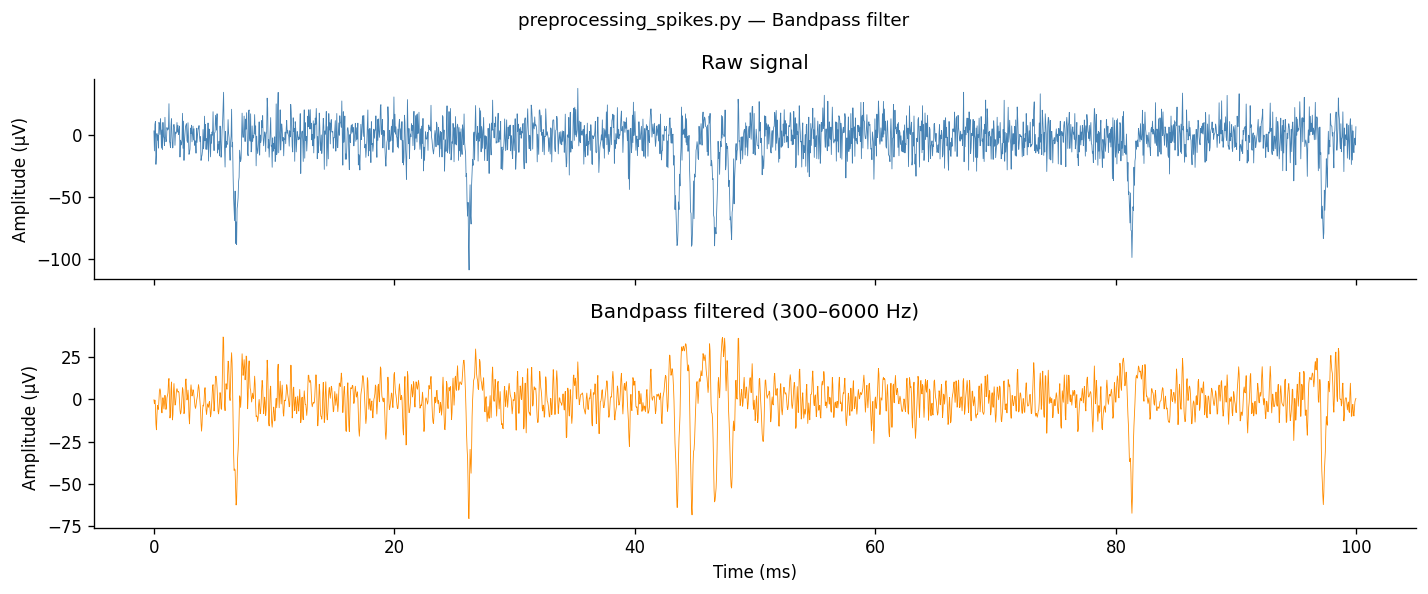

In [5]:
# ── Bandpass filter (300–6000 Hz) ────────────────────────────────────────────

def bandpass_filter(data, fs, lowcut=300.0, highcut=6000.0, order=4):
    """Zero-phase Butterworth bandpass filter."""
    sos = butter(order, [lowcut, highcut], btype='band', fs=fs, output='sos')
    return sosfiltfilt(sos, data)

filtered = bandpass_filter(signal, FS_RAW)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
n_disp = int(0.1 * FS_RAW)
axes[0].plot(t_raw[:n_disp] * 1000, signal[:n_disp],   lw=0.5, color='steelblue')
axes[0].set_ylabel('Amplitude (µV)'); axes[0].set_title('Raw signal')
axes[1].plot(t_raw[:n_disp] * 1000, filtered[:n_disp], lw=0.5, color='darkorange')
axes[1].set_xlabel('Time (ms)'); axes[1].set_ylabel('Amplitude (µV)')
axes[1].set_title('Bandpass filtered (300–6000 Hz)')
plt.suptitle('preprocessing_spikes.py — Bandpass filter', fontsize=11)
plt.tight_layout(); plt.show()

Threshold: -47.12 µV | Detected: 47062 spikes
Overall FR: 78.4 Hz


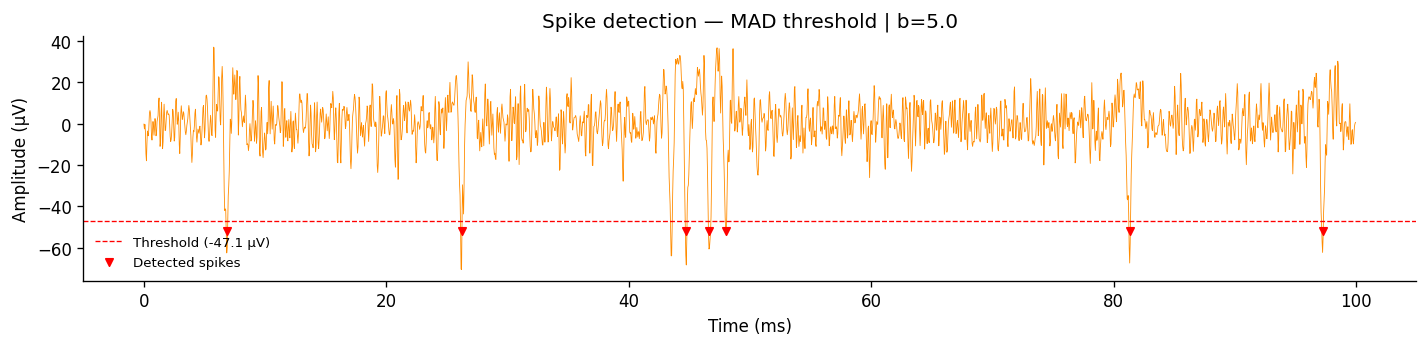

In [6]:
# ── Spike detection (MAD threshold) ──────────────────────────────────────────

THRESH_MULT   = 5.0
REFRACTORY_MS = 1.0
PEAK_SEARCH_MS = 2.0

def detect_spikes_mad(data, fs, b=5.0, polarity='neg',
                       refractory_ms=1.0, peak_search_ms=2.0):
    """
    Threshold-based spike detection using MAD noise estimate.
    Threshold = b * MAD where MAD = median(|x|) / 0.6745.
    """
    mad       = np.median(np.abs(data - np.median(data))) / 0.6745
    threshold = b * mad
    sig       = -data if polarity == 'neg' else data
    above     = sig > threshold
    crossings = np.where(np.diff(above.astype(int)) == 1)[0]

    search_samples = int(peak_search_ms / 1000 * fs)
    refr_samples   = int(refractory_ms  / 1000 * fs)
    peaks, last_pk = [], -refr_samples

    for c in crossings:
        if c - last_pk < refr_samples:
            continue
        end = min(c + search_samples, len(sig))
        pk  = c + np.argmax(sig[c:end])
        if pk - last_pk >= refr_samples:
            peaks.append(pk)
            last_pk = pk

    return np.array(peaks, dtype=float) / fs, (-threshold if polarity == 'neg' else threshold)

detected_times, threshold = detect_spikes_mad(filtered, FS_RAW)
print(f'Threshold: {threshold:.2f} µV | Detected: {len(detected_times)} spikes')
print(f'Overall FR: {len(detected_times)/DURATION_S:.1f} Hz')

# Save synthetic pkl
tmpdir   = tempfile.mkdtemp()
pkl_path = os.path.join(tmpdir, 'detected_ch31.pkl')
with open(pkl_path, 'wb') as f:
    pickle.dump({'spike_times_s': detected_times, 'channel': 31,
                 'threshold': threshold, 'fs': FS_RAW}, f)

# QC plot: 100 ms of filtered signal
fig, ax = plt.subplots(figsize=(12, 3))
n_disp  = int(0.1 * FS_RAW)
ax.plot(t_raw[:n_disp] * 1000, filtered[:n_disp], lw=0.5, color='darkorange')
ax.axhline(threshold, color='red', lw=0.8, ls='--', label=f'Threshold ({threshold:.1f} µV)')
spk_win = detected_times[detected_times < 0.1]
ax.scatter(spk_win * 1000, [threshold * 1.1] * len(spk_win),
           marker='v', color='red', s=20, zorder=5, label='Detected spikes')
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Amplitude (µV)')
ax.set_title(f'Spike detection — MAD threshold | b={THRESH_MULT}')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

---
## Step 4 — ISI Analysis (`process_spikes_isi.py`)

- **ISI histogram** — distribution of intervals between consecutive spikes, normalised as fraction of total ISIs
- **Burst fraction** — fraction of ISIs < 6 ms, indicating burst firing

In [7]:
# ── ISI computation ───────────────────────────────────────────────────────────

MAX_ISI_S       = 0.025   # 25 ms zoom window
BIN_S           = 0.0005  # 0.5 ms bins
BURST_THRESH_MS = 6.0
FULL_ISI_MAX_S  = 1.0

baseline_win = [(0.0,       BASELINE_S)]
stim_win     = [(STIM_ONSET, DURATION_S)]

def restrict_spikes(times, windows):
    mask = np.zeros(len(times), dtype=bool)
    for start, end in windows:
        mask |= (times >= start) & (times < end)
    return times[mask]

def compute_isi(times):
    return np.diff(np.sort(times)) if len(times) > 1 else np.array([])

def normalize_histogram(values, bin_edges):
    """Fraction of ISIs per bin — normalised over the full ISI range."""
    counts, _ = np.histogram(values, bins=bin_edges)
    total = counts.sum()
    return counts / total if total > 0 else np.zeros(len(counts))

bin_edges  = np.arange(0, FULL_ISI_MAX_S + BIN_S, BIN_S)
centers_ms = (bin_edges[:-1] + np.diff(bin_edges) / 2.0) * 1000.0
zoom_mask  = centers_ms <= MAX_ISI_S * 1000.0

spikes_base = restrict_spikes(detected_times, baseline_win)
spikes_stim = restrict_spikes(detected_times, stim_win)
isi_base    = compute_isi(spikes_base)
isi_stim    = compute_isi(spikes_stim)
hist_base   = normalize_histogram(isi_base, bin_edges)
hist_stim   = normalize_histogram(isi_stim, bin_edges)

burst_frac_base = np.mean(isi_base < BURST_THRESH_MS / 1000) if len(isi_base) else 0
burst_frac_stim = np.mean(isi_stim < BURST_THRESH_MS / 1000) if len(isi_stim) else 0

print(f'Baseline: {len(spikes_base)} spikes | FR = {len(spikes_base)/BASELINE_S:.1f} Hz | burst = {burst_frac_base:.3f}')
print(f'Stim:     {len(spikes_stim)} spikes | FR = {len(spikes_stim)/STIM_S:.1f} Hz | burst = {burst_frac_stim:.3f}')


Baseline: 25913 spikes | FR = 86.4 Hz | burst = 0.359
Stim:     21149 spikes | FR = 70.5 Hz | burst = 0.294


---
## Step 5 — PSTH Computation (`process_spikes_psth.py`)

For each channel, firing rates are computed in 5 s bins separately for baseline and stimulation epochs. Both epochs start at t=0 and run for 300 s, so they can be directly compared. Outputs are aggregated across channels within each animal and saved as pkl files for postprocessing.

In [8]:
# ── PSTH computation (`process_spikes_psth.py`) ──────────────────────────────
# For each channel, firing rates are computed in 5 s bins separately
# for baseline and stimulation epochs, each starting at t=0.
# Outputs are saved as pkl files and aggregated across channels within animal.

FULL_BIN_S  = 5.0    # 5 s bins
EPOCH_DUR_S = 300.0  # both epochs are 300 s

bin_edges   = np.arange(0.0, EPOCH_DUR_S + FULL_BIN_S, FULL_BIN_S)
bin_centers = bin_edges[:-1] + np.diff(bin_edges) / 2.0

def psth_from_spikes(spike_times_abs, epoch_start, bin_edges):
    """
    Compute firing rate (Hz) per bin for one epoch.
    spike_times_abs : spike times in absolute recording time (s)
    epoch_start     : onset of the epoch in absolute time (s)
    bin_edges       : bin edges relative to epoch onset (0 to EPOCH_DUR_S)
    """
    relative = spike_times_abs - epoch_start
    in_epoch = relative[(relative >= 0) & (relative < EPOCH_DUR_S)]
    counts, _ = np.histogram(in_epoch, bins=bin_edges)
    return counts / np.diff(bin_edges)   # Hz

# Simulate 3 animals × 1 channel each
psth_arr_b, psth_arr_s = [], []
for _ in range(3):
    t_b = poisson_spike_times(FR_BASE + RNG.uniform(-5, 5),
                               BASELINE_S, offset_s=0.0,        rng=RNG)
    t_s = poisson_spike_times(FR_STIM + RNG.uniform(-5, 5),
                               STIM_S,     offset_s=STIM_ONSET, rng=RNG)
    # Baseline PSTH: t=0 is start of baseline epoch
    psth_arr_b.append(psth_from_spikes(t_b, epoch_start=0.0,        bin_edges=bin_edges))
    # Stimulation PSTH: t=0 is stimulation onset
    psth_arr_s.append(psth_from_spikes(t_s, epoch_start=STIM_ONSET, bin_edges=bin_edges))

print(f"Per-animal PSTH computed: {len(psth_arr_b)} animals x {len(bin_centers)} bins")
print(f"Bin width: {FULL_BIN_S:.0f} s | Epoch duration: {EPOCH_DUR_S:.0f} s")


Per-animal PSTH computed: 3 animals x 60 bins
Bin width: 5 s | Epoch duration: 300 s


---
## Step 6 — ISI + Burst Fraction GA (`postprocess_spikes_isi_mainfigure.py`)

- ISI histograms averaged across animals (mean ± SEM)
- Burst fraction compared baseline vs. stimulation per animal using a Gardner-Altman estimation plot with 95% bootstrap CI

Note: color and font adjustments were applied in Inkscape for the published figures. All values are fully reproducible from the scripts.

Burst fractions:
  animal  burst_fraction_baseline  burst_fraction_stim
Animal_1                 0.444342             0.385578
Animal_2                 0.457587             0.368965
Animal_3                 0.455885             0.399151


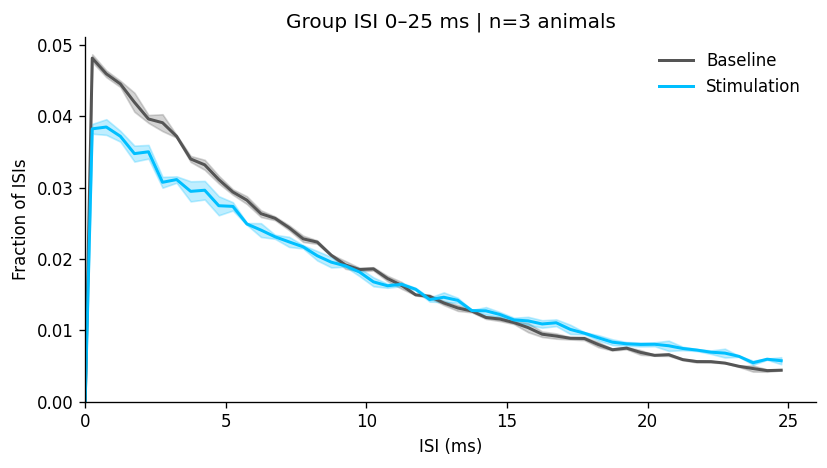

In [20]:
# ── ISI (n=3 simulated animals) ────────────────────────────────────────

isi_bin_edges   = np.arange(0, FULL_ISI_MAX_S + BIN_S, BIN_S)
isi_centers_ms  = (isi_bin_edges[:-1] + np.diff(isi_bin_edges) / 2.0) * 1000.0
isi_zoom_mask   = isi_centers_ms <= MAX_ISI_S * 1000.0

N_ANIMALS = 3  # number of simulated animals

animal_hists_base, animal_hists_stim, burst_fracs = [], [], []

for i in range(N_ANIMALS):
    t_b = poisson_spike_times(FR_BASE + RNG.uniform(-5, 5), BASELINE_S, offset_s=0.0,        rng=RNG)
    t_s = poisson_spike_times(FR_STIM + RNG.uniform(-5, 5), STIM_S,     offset_s=STIM_ONSET, rng=RNG)
    isi_b = compute_isi(t_b); isi_s = compute_isi(t_s)
    animal_hists_base.append(normalize_histogram(isi_b, isi_bin_edges))
    animal_hists_stim.append(normalize_histogram(isi_s, isi_bin_edges))
    burst_fracs.append({
        'animal':                f'Animal_{i+1}',
        'burst_fraction_baseline': float(np.mean(isi_b < BURST_THRESH_MS / 1000)),
        'burst_fraction_stim':     float(np.mean(isi_s < BURST_THRESH_MS / 1000)),
    })

arr_b  = np.vstack(animal_hists_base); arr_s = np.vstack(animal_hists_stim)
mean_b = arr_b.mean(0); sem_b = arr_b.std(0, ddof=1) / np.sqrt(N_ANIMALS)
mean_s = arr_s.mean(0); sem_s = arr_s.std(0, ddof=1) / np.sqrt(N_ANIMALS)
df_burst = pd.DataFrame(burst_fracs)

print('Burst fractions:'); print(df_burst.to_string(index=False))

x_zoom   = np.concatenate([[0.0], isi_centers_ms[isi_zoom_mask]])
mb_zoom  = np.concatenate([[0.0], mean_b[isi_zoom_mask]])
sb_zoom  = np.concatenate([[0.0], sem_b[isi_zoom_mask]])
ms_zoom  = np.concatenate([[0.0], mean_s[isi_zoom_mask]])
ss_zoom  = np.concatenate([[0.0], sem_s[isi_zoom_mask]])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_zoom, mb_zoom, color=BASE_COLOR, lw=1.8, label='Baseline')
ax.fill_between(x_zoom, mb_zoom - sb_zoom, mb_zoom + sb_zoom,
                color=BASE_COLOR, alpha=0.25)
ax.plot(x_zoom, ms_zoom, color=TOOL_COLOR, lw=1.8, label='Stimulation')
ax.fill_between(x_zoom, ms_zoom - ss_zoom, ms_zoom + ss_zoom,
                color=TOOL_COLOR, alpha=0.25)
ax.set_xlabel('ISI (ms)'); ax.set_ylabel('Fraction of ISIs')
ax.set_title(f'Group ISI 0–{int(MAX_ISI_S*1000)} ms | n={N_ANIMALS} animals')
ax.set_xlim(left=0)
ax.set_xticks(range(0, int(MAX_ISI_S*1000)+1, 5))
ax.set_ylim(bottom=0)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

Burst fraction CI:
   difference   bca_low  bca_high
0    -0.07587 -0.097503 -0.056257


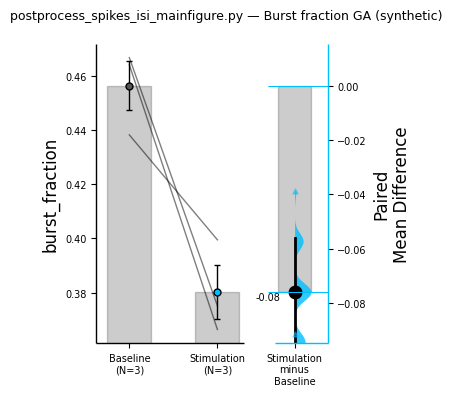

In [18]:
# ── Burst fraction Gardner-Altman plot ────────────────────────────────────────

df_est = pd.DataFrame({
    'id':        list(range(N_ANIMALS)) * 2,
    'condition': ['Baseline'] * N_ANIMALS + ['Stimulation'] * N_ANIMALS,
    'burst_fraction': (
        list(df_burst['burst_fraction_baseline']) +
        list(df_burst['burst_fraction_stim'])
    ),
})

dabest_data = dabest.load(df_est, idx=('Baseline', 'Stimulation'),
                           paired='sequential', id_col='id',
                           x='condition', y='burst_fraction')
mean_diff = dabest_data.mean_diff

stats = mean_diff.statistical_tests
print('Burst fraction CI:')
print(stats[['difference', 'bca_low', 'bca_high']] if 'difference' in stats.columns else stats)

est_plot = mean_diff.plot(
    custom_palette={'Baseline': BASE_COLOR, 'Stimulation': TOOL_COLOR},
    show_pairs=True,
)
fig = est_plot.figure
ax_left = fig.axes[0]

# Mean ± SEM overlay
for x_pos, col, color in [
    (0, 'burst_fraction_baseline', BASE_COLOR),
    (1, 'burst_fraction_stim',     TOOL_COLOR),
]:
    vals = df_burst[col].values
    ax_left.errorbar(x=x_pos, y=vals.mean(),
                     yerr=vals.std(ddof=1) / np.sqrt(len(vals)),
                     fmt='o', color='black', markerfacecolor=color,
                     markersize=5, elinewidth=1.0, capsize=2, zorder=6)

for ax in fig.axes:
    ax.tick_params(labelsize=7)
    for txt in ax.texts: txt.set_fontsize(7)

for coll in fig.axes[1].collections:
    try: coll.set_facecolor(TOOL_COLOR); coll.set_edgecolor(TOOL_COLOR)
    except Exception: pass

fig.suptitle('postprocess_spikes_isi_mainfigure.py — Burst fraction GA (synthetic)', fontsize=9)
plt.show()

---
## Step 7 — MUA firing Rate Gardner-Altman (`postprocess_spikes_GA_channels.py`)

Channel-level firing rates compared baseline vs. stimulation. Each data point = one electrode channel.

**Comparison periods in the script:**
- `full` — used in the paper
- `early` / `late` — exploratory, not reported in the paper

Note: color and font adjustments were applied in Inkscape for the published figures.

Channels: 9 | Mean baseline: 101.7 Hz | Mean stim: 81.7 Hz | Mean Δ: -20.0 Hz

MUA firing rate CI:
   difference   bca_low  bca_high
0  -20.011116 -24.31598 -14.49264


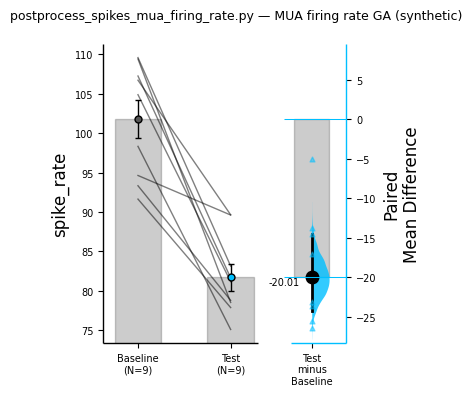

In [17]:
# ── Channel-level firing rates (3 animals × 3 channels) ──────────────────────

N_CHANNELS = 3
rows = []
for a in range(N_ANIMALS):
    for ch in range(N_CHANNELS):
        rows.append({
            'folder':            f'Animal_{a+1}',
            'channel':           ch + 1,
            'baseline_rate_hz':  FR_BASE + RNG.uniform(-10, 10),
            'full_stim_rate_hz': FR_STIM + RNG.uniform(-10, 10),
        })
df_rates = pd.DataFrame(rows)

print(f'Channels: {len(df_rates)} | Mean baseline: {df_rates["baseline_rate_hz"].mean():.1f} Hz | '
      f'Mean stim: {df_rates["full_stim_rate_hz"].mean():.1f} Hz | '
      f'Mean \u0394: {(df_rates["full_stim_rate_hz"]-df_rates["baseline_rate_hz"]).mean():.1f} Hz')

df_est2 = pd.DataFrame({
    'id':        list(range(len(df_rates))) * 2,
    'condition': ['Baseline'] * len(df_rates) + ['Test'] * len(df_rates),
    'spike_rate': list(df_rates['baseline_rate_hz']) + list(df_rates['full_stim_rate_hz']),
})

dabest_data2 = dabest.load(df_est2, idx=('Baseline', 'Test'),
                            paired='sequential', id_col='id',
                            x='condition', y='spike_rate')
mean_diff2 = dabest_data2.mean_diff

stats2 = mean_diff2.statistical_tests
print('\nMUA firing rate CI:')
print(stats2[['difference', 'bca_low', 'bca_high']] if 'difference' in stats2.columns else stats2)

est_plot2 = mean_diff2.plot(
    custom_palette={'Baseline': BASE_COLOR, 'Test': TOOL_COLOR},
    show_pairs=True,
)
fig2    = est_plot2.figure
ax_left = fig2.axes[0]

for x_pos, col, color in [
    (0, 'baseline_rate_hz',  BASE_COLOR),
    (1, 'full_stim_rate_hz', TOOL_COLOR),
]:
    vals = df_rates[col].values
    ax_left.errorbar(x=x_pos, y=vals.mean(),
                     yerr=vals.std(ddof=1) / np.sqrt(len(vals)),
                     fmt='o', color='black', markerfacecolor=color,
                     markersize=5, elinewidth=1.0, capsize=2, zorder=6)

for ax in fig2.axes:
    ax.tick_params(labelsize=7)
    for txt in ax.texts: txt.set_fontsize(7)

for coll in fig2.axes[1].collections:
    try: coll.set_facecolor(TOOL_COLOR); coll.set_edgecolor(TOOL_COLOR)
    except Exception: pass

fig2.suptitle('postprocess_spikes_mua_firing_rate.py — MUA firing rate GA (synthetic)', fontsize=9)
plt.show()

---
## Step 8 — Full-epoch PSTH Plot (`postprocess_spikes_psth_supplement.py`)

Group averaging (mean ± SEM across animals) of the per-animal PSTHs from Step 5, followed by Gaussian smoothing for display. Maximum suppression is detected from the **unsmoothed** group-mean delta (stimulation − baseline), then marked as a vertical dotted line.

Note: color and font adjustments were applied in Inkscape for the published figures.

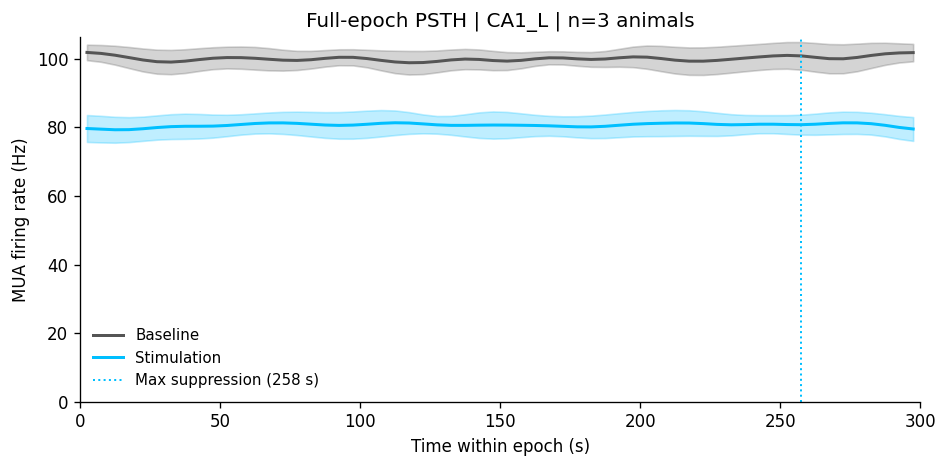

Max suppression: delta = -27.9 Hz at t = 258 s


In [16]:
# ── Full-epoch PSTH plot (`postprocess_spikes_psth_mainfigure.py`) ───────────
# Group averaging (mean ± SEM across animals) and plotting.
# Maximum suppression is detected from the UNSMOOTHED group-mean delta,
# then shown as a vertical dotted line on the smoothed figure.

SMOOTH_SIGMA = 2.0   # Gaussian sigma in bins (display only)
N_ANIMALS    = len(psth_arr_b)

arr_b_mat = np.vstack(psth_arr_b)
arr_s_mat = np.vstack(psth_arr_s)
mean_b = arr_b_mat.mean(0); sem_b = arr_b_mat.std(0, ddof=1) / np.sqrt(N_ANIMALS)
mean_s = arr_s_mat.mean(0); sem_s = arr_s_mat.std(0, ddof=1) / np.sqrt(N_ANIMALS)

# Maximum suppression from UNSMOOTHED delta (matches real script)
delta      = mean_s - mean_b
n_min      = int(np.argmin(delta))
t_max_supp = float(bin_centers[n_min])
delta_max  = float(delta[n_min])

# Gaussian smoothing for display only
sm_b     = gaussian_filter1d(mean_b, sigma=SMOOTH_SIGMA)
sm_b_sem = gaussian_filter1d(sem_b,  sigma=SMOOTH_SIGMA)
sm_s     = gaussian_filter1d(mean_s, sigma=SMOOTH_SIGMA)
sm_s_sem = gaussian_filter1d(sem_s,  sigma=SMOOTH_SIGMA)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bin_centers, sm_b, color=BASE_COLOR, lw=1.8, label='Baseline')
ax.fill_between(bin_centers, sm_b - sm_b_sem, sm_b + sm_b_sem,
                color=BASE_COLOR, alpha=0.25)
ax.plot(bin_centers, sm_s, color=TOOL_COLOR, lw=1.8, label='Stimulation')
ax.fill_between(bin_centers, sm_s - sm_s_sem, sm_s + sm_s_sem,
                color=TOOL_COLOR, alpha=0.25)
ax.axvline(t_max_supp, color=TOOL_COLOR, lw=1.2, ls=':',
           label=f'Max suppression ({t_max_supp:.0f} s)')
ax.set_xlabel('Time within epoch (s)')
ax.set_ylabel('MUA firing rate (Hz)')
ax.set_title(f'Full-epoch PSTH | CA1_L | n={N_ANIMALS} animals')
ax.set_xlim(bin_edges[0], bin_edges[-1])
ax.set_ylim(bottom=0)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print(f'Max suppression: delta = {delta_max:.1f} Hz at t = {t_max_supp:.0f} s')


---
## Step 9 — Full ISI Distribution (`postprocess_spikes_isi_supplement.py`)

Shows the complete ISI distribution up to 150 ms (rather than the 25 ms zoom used in the main figure), averaged across animals with mean ± SEM shading. This plot is included in the supplement.

Key differences from the main-figure ISI (Step 6):
- **Range**: 0–150 ms instead of 0–25 ms
- **Bin size**: 1 ms instead of 0.5 ms
- **Normalization**: fraction of ISIs within [0, 150 ms] — clipped before histogramming
- **Purpose**: shows the full temporal structure of spike trains including longer intervals

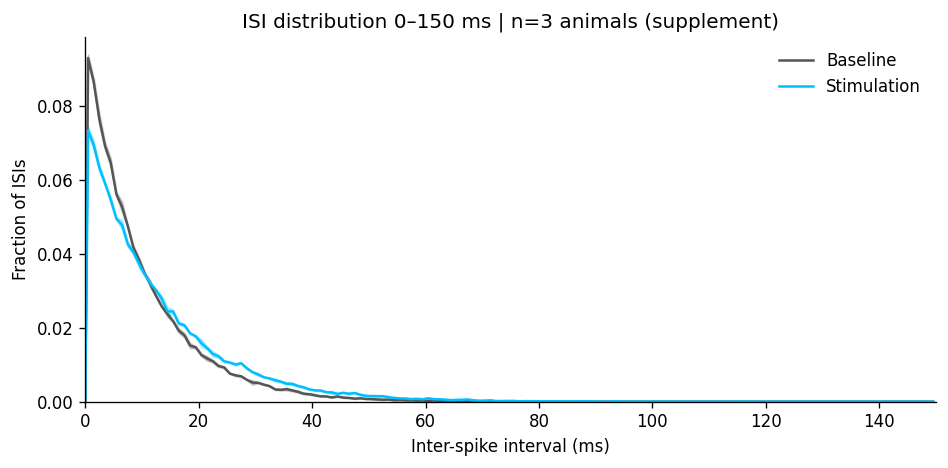

In [13]:
# ── Full ISI distribution (`postprocess_spikes_isi_group.py`) ─────────────────
# Shows ISI distribution up to MAX_ISI_GROUP_S (150 ms) for the supplement.
# Normalization is over the clipped range [0, MAX_ISI_GROUP_S], not the full
# distribution — consistent with the real script.

MAX_ISI_GROUP_S  = 0.150   # 150 ms — full range for supplement
BIN_GROUP_S      = 0.001   # 1 ms bins
N_ANIMALS_GROUP  = 3

group_bin_edges   = np.arange(0.0, MAX_ISI_GROUP_S + BIN_GROUP_S, BIN_GROUP_S)
group_centers_ms  = (group_bin_edges[:-1] + np.diff(group_bin_edges) / 2.0) * 1000.0

def normalize_histogram_group(values, bin_edges):
    """
    Fraction of ISIs per bin.
    Note: ISIs are clipped to [0, MAX_ISI_GROUP_S] before histogramming,
    so the normalization is relative to the clipped range (matches real script).
    """
    clipped = values[(values >= 0) & (values <= MAX_ISI_GROUP_S)]
    counts, _ = np.histogram(clipped, bins=bin_edges)
    total = counts.sum()
    return counts / total if total > 0 else np.zeros(len(counts))

group_hists_base, group_hists_stim = [], []

for _ in range(N_ANIMALS_GROUP):
    t_b = poisson_spike_times(FR_BASE + RNG.uniform(-5, 5),
                               BASELINE_S, offset_s=0.0,        rng=RNG)
    t_s = poisson_spike_times(FR_STIM + RNG.uniform(-5, 5),
                               STIM_S,     offset_s=STIM_ONSET, rng=RNG)
    isi_b = compute_isi(t_b)
    isi_s = compute_isi(t_s)
    group_hists_base.append(normalize_histogram_group(isi_b, group_bin_edges))
    group_hists_stim.append(normalize_histogram_group(isi_s, group_bin_edges))

arr_gb   = np.vstack(group_hists_base)
arr_gs   = np.vstack(group_hists_stim)
mean_gb  = arr_gb.mean(0); sem_gb = arr_gb.std(0, ddof=1) / np.sqrt(N_ANIMALS_GROUP)
mean_gs  = arr_gs.mean(0); sem_gs = arr_gs.std(0, ddof=1) / np.sqrt(N_ANIMALS_GROUP)

# Prepend (0, 0) so curves start at the origin.
x_grp  = np.concatenate([[0.0], group_centers_ms])
mgb    = np.concatenate([[0.0], mean_gb])
sgb    = np.concatenate([[0.0], sem_gb])
mgs    = np.concatenate([[0.0], mean_gs])
sgs    = np.concatenate([[0.0], sem_gs])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_grp, mgb, color=BASE_COLOR, lw=1.5, label='Baseline')
ax.fill_between(x_grp, mgb - sgb, mgb + sgb,
                color=BASE_COLOR, alpha=0.25)
ax.plot(x_grp, mgs, color=TOOL_COLOR, lw=1.5, label='Stimulation')
ax.fill_between(x_grp, mgs - sgs, mgs + sgs,
                color=TOOL_COLOR, alpha=0.25)
ax.set_xlabel('Inter-spike interval (ms)')
ax.set_ylabel('Fraction of ISIs')
ax.set_title(f'ISI distribution 0–{int(MAX_ISI_GROUP_S*1000)} ms | n={N_ANIMALS_GROUP} animals (supplement)')
ax.set_xlim(left=0, right=MAX_ISI_GROUP_S * 1000)
ax.set_ylim(bottom=0)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


---
## Summary — Output Files

```
Postprocessing/
├── Spike_ISI_MainFigure/{region}/{kind}/{window_suffix}/
│   ├── ISI_zoom_*.png / .svg
│   ├── BurstFraction_*.png / .svg
│   └── BurstFractionStats_*.csv        (mean diff, BCa CI)
├── Spike_MUA_firing_rate/{region}/{kind}/{window_suffix}/
│   ├── EstimationPlot_*.png / .svg
│   ├── EstimationStats_*.csv           (mean diff, BCa CI)
│   └── channel_rates.csv
├── Spike_PSTH_Supplement/{region}/{kind}/{window_suffix}/
|   ├── FullEpochPSTH_*.png / .svg
|   └── group_full_epoch_psth.csv
├── Spike_ISI_Supplement/{region}/{kind}/{window_suffix}/
│   ├── full_isi_distribution.csv
|   └── ISI_full_*.png / .svg
```

---
## Note on figure post-processing

Color, line width, and font adjustments were applied in Inkscape for the published figures. All data values and statistical results are fully reproducible from the scripts.

---
## References

Ho, J., Tumkaya, T., Aryal, S., et al. (2019). Moving beyond P values: data analysis with estimation graphics. *Nature Methods*, 16, 565–566. https://doi.org/10.1038/s41592-019-0470-3